FOURTH MODEL SUBMISSION — SUPPORT VECTOR MACHINE (SVM)

Step 1 — Import Libraries

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Step 2 — Load Data

In [2]:
# Step 2: Load train, test, and sample_submission
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head()


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


Step 3 — Inspect Data

In [3]:
# Step 3: Inspect structure
print(train.shape)
print(train.dtypes)
print(train.isnull().sum())

print(train["NObeyesdad"].value_counts())


(20758, 18)
id                                  int64
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object
id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FA

Step 4 — Separate Features and Target

In [4]:
# Step 4: Separate X and y
target = "NObeyesdad"

X = train.drop(columns=[target])
y = train[target]

# Remove ID column if present
if "id" in X.columns:
    X = X.drop(columns=["id"])

# Prepare test set
test_ids = test["id"] if "id" in test.columns else None
X_test = test.drop(columns=["id"]) if "id" in test.columns else test


Step 5 — Identify Numeric and Categorical Columns

In [5]:
# Step 5: Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features


(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'],
 ['Gender',
  'family_history_with_overweight',
  'FAVC',
  'CAEC',
  'SMOKE',
  'SCC',
  'CALC',
  'MTRANS'])

Step 6 — Build Preprocessing + SVM Pipeline

In [6]:
# Step 6: Preprocessing + SVM pipeline

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

svm_clf = SVC(
    kernel="rbf",          # nonlinear kernel
    C=1.0,                 # regularization strength
    gamma="scale",         # kernel coefficient
    probability=False,     # class labels only
    random_state=42
)

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", svm_clf)
])


Step 7 – Train/validation split and fit SVM

In [7]:
# Step 7 (SVM): Train/validation split
X_train_svm, X_valid_svm, y_train_svm, y_valid_svm = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit SVM pipeline
svm_pipeline.fit(X_train_svm, y_train_svm)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model', SVC(random_state=42))])

Step 8 – Evaluate SVM on validation set

In [8]:
# Step 8 (SVM): Evaluate
y_pred_valid_svm = svm_pipeline.predict(X_valid_svm)

print("Validation accuracy (SVM):", accuracy_score(y_valid_svm, y_pred_valid_svm))
print("\nClassification report (SVM):\n", classification_report(y_valid_svm, y_pred_valid_svm))
print("\nConfusion matrix (SVM):\n", confusion_matrix(y_valid_svm, y_pred_valid_svm))


Validation accuracy (SVM): 0.8810211946050096

Classification report (SVM):
                      precision    recall  f1-score   support

Insufficient_Weight       0.90      0.93      0.92       505
      Normal_Weight       0.86      0.83      0.84       617
     Obesity_Type_I       0.85      0.88      0.87       582
    Obesity_Type_II       0.96      0.97      0.96       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.74      0.70      0.72       485
Overweight_Level_II       0.77      0.77      0.77       504

           accuracy                           0.88      4152
          macro avg       0.87      0.87      0.87      4152
       weighted avg       0.88      0.88      0.88      4152


Confusion matrix (SVM):
 [[472  32   0   0   0   1   0]
 [ 47 510   1   0   0  51   8]
 [  1   0 513  21   3  12  32]
 [  0   0  19 630   0   0   1]
 [  0   0   2   1 806   0   0]
 [  2  47  18   1   0 340  77]
 [  0   6  47   6   0  58 387]]


Step 9 — Confusion Matrix Heatmap

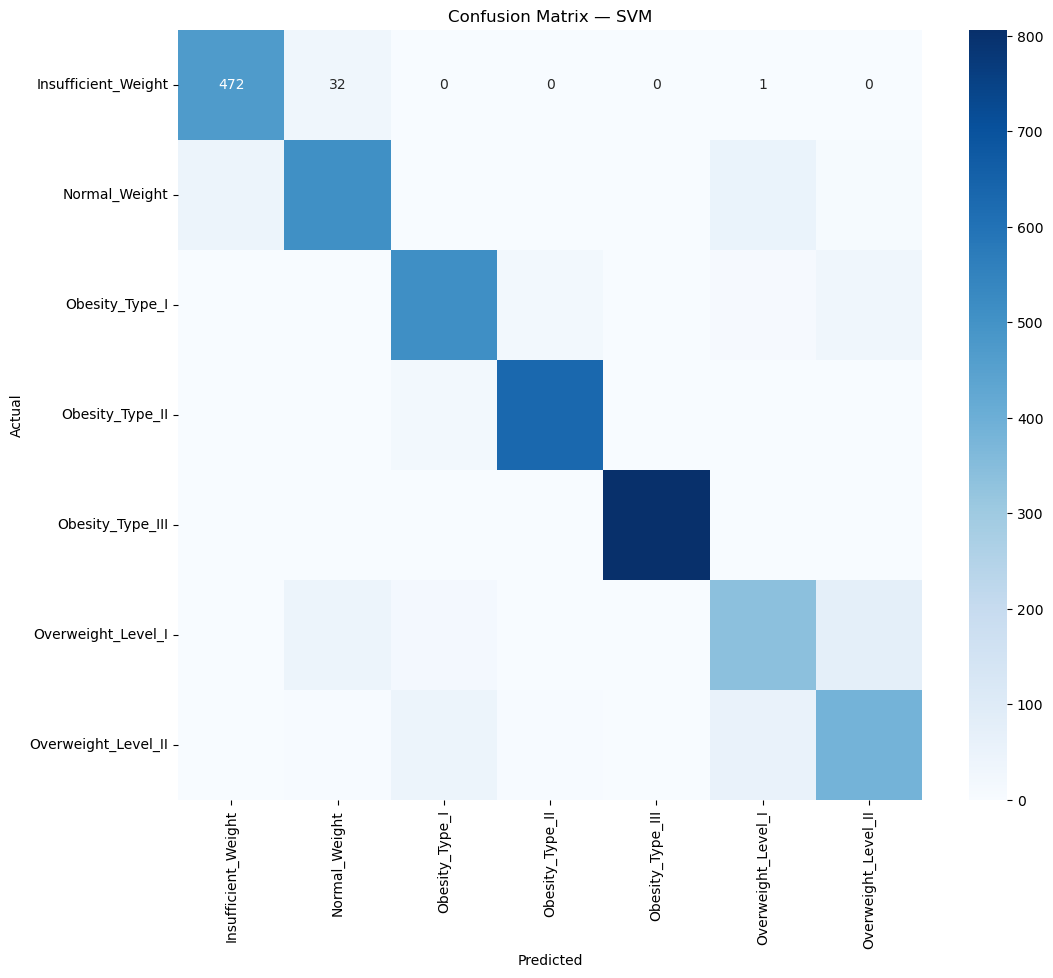

In [9]:
# Step 9: Confusion matrix heatmap
plt.figure(figsize=(12,10))
cm = confusion_matrix(y_valid_svm, y_pred_valid_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=svm_pipeline.classes_,
            yticklabels=svm_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SVM")

plt.savefig("Obesity-Risk-ML-Classification/Model_4_Support Vector Machine (SVM)/reports/figures/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


Step 10 — Classification Report Heatmap

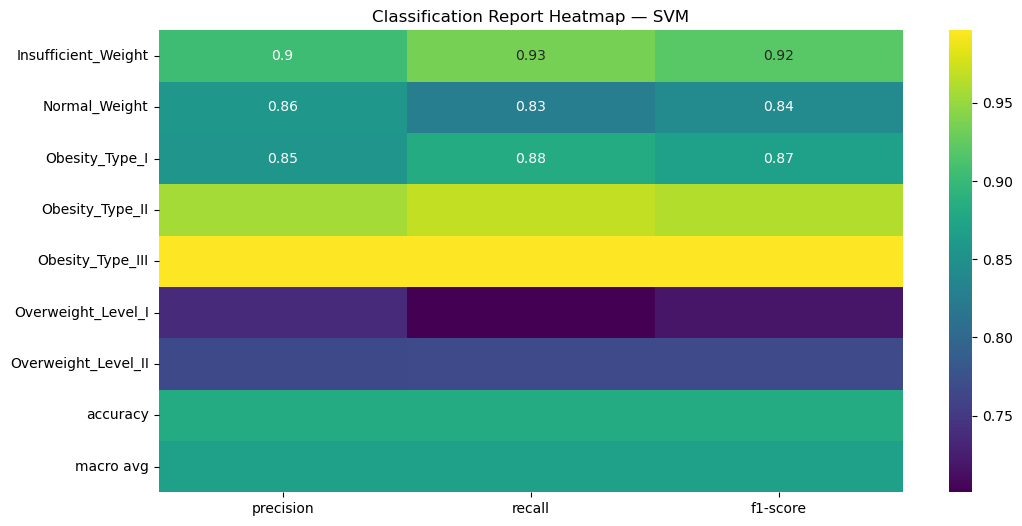

In [10]:
# Step 10: Classification report heatmap
report = classification_report(y_valid_svm, y_pred_valid_svm, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(12,6))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="viridis")
plt.title("Classification Report Heatmap — SVM")

plt.savefig("Obesity-Risk-ML-Classification/Model_4_Support Vector Machine (SVM)/reports/figures/classification_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


Step 11 — Support Vector Count Visualization

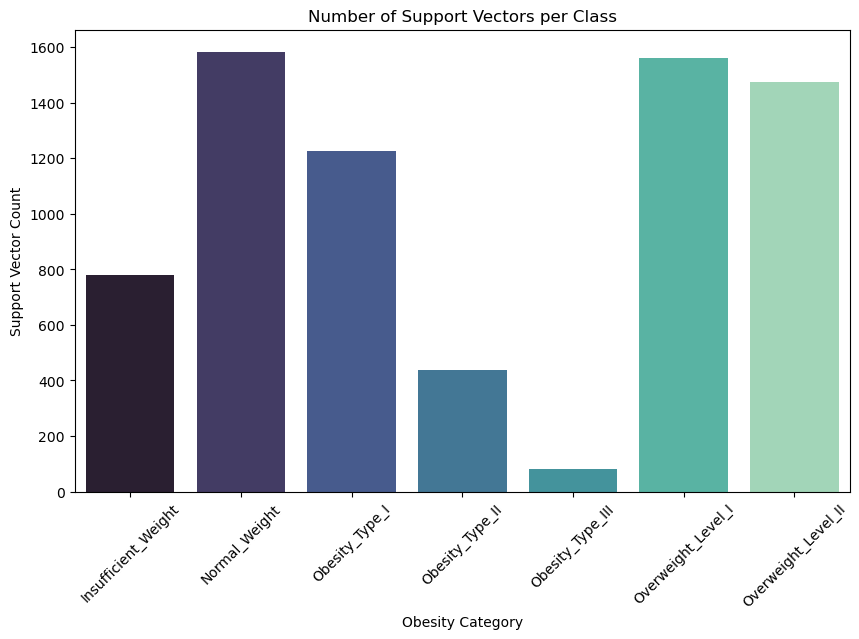

In [11]:
# Step 11: Number of support vectors per class
support_counts = pd.Series(svm_pipeline.named_steps["model"].n_support_,
                           index=svm_pipeline.classes_)

plt.figure(figsize=(10,6))
sns.barplot(x=support_counts.index, y=support_counts.values, palette="mako")
plt.title("Number of Support Vectors per Class")
plt.xlabel("Obesity Category")
plt.ylabel("Support Vector Count")
plt.xticks(rotation=45)

plt.savefig("Obesity-Risk-ML-Classification/Model_4_Support Vector Machine (SVM)/reports/figures/support_vectors_per_class.png", dpi=300, bbox_inches="tight")
plt.show()


Step 12 — Support Vector Distribution (Scatter Plot)

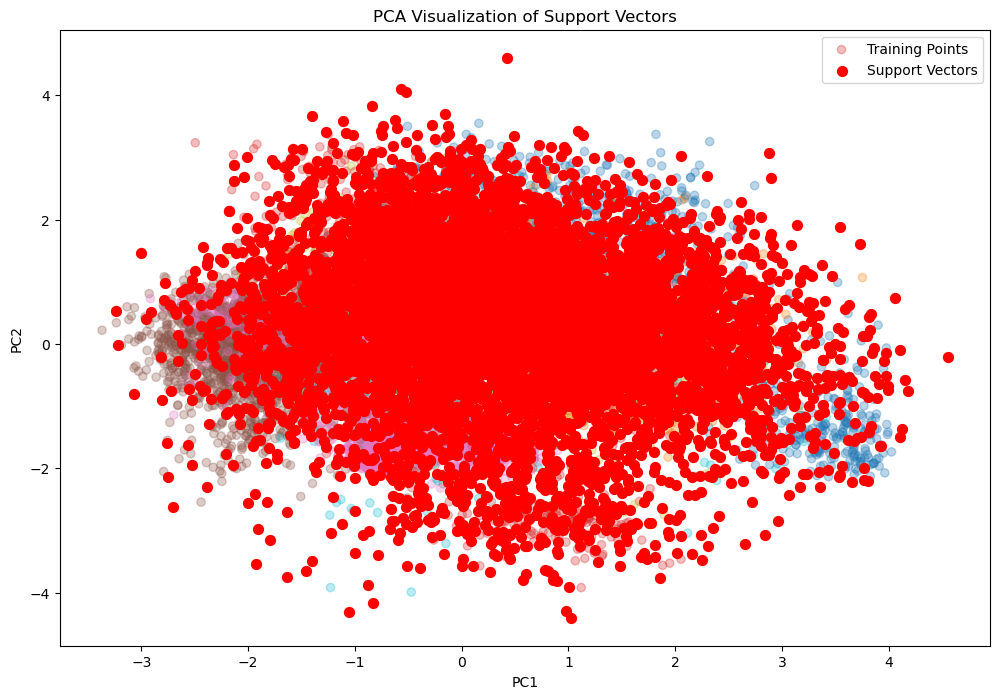

In [12]:
# Step 12: PCA visualization of support vectors
from sklearn.decomposition import PCA

# Extract transformed training data
X_train_transformed = svm_pipeline.named_steps["preprocessor"].transform(X_train_svm)

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_transformed)

# Identify support vectors
sv_indices = svm_pipeline.named_steps["model"].support_

plt.figure(figsize=(12,8))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train_svm.map({c:i for i,c in enumerate(svm_pipeline.classes_)}),
            cmap="tab10", alpha=0.3, label="Training Points")

plt.scatter(X_pca[sv_indices,0], X_pca[sv_indices,1], 
            color="red", s=50, label="Support Vectors")

plt.title("PCA Visualization of Support Vectors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.savefig("Obesity-Risk-ML-Classification/Model_4_Support Vector Machine (SVM)/reports/figures/support_vectors.png", dpi=300, bbox_inches="tight")

plt.show()


Step 13 — Kernel Influence Visualization (RBF Kernel)

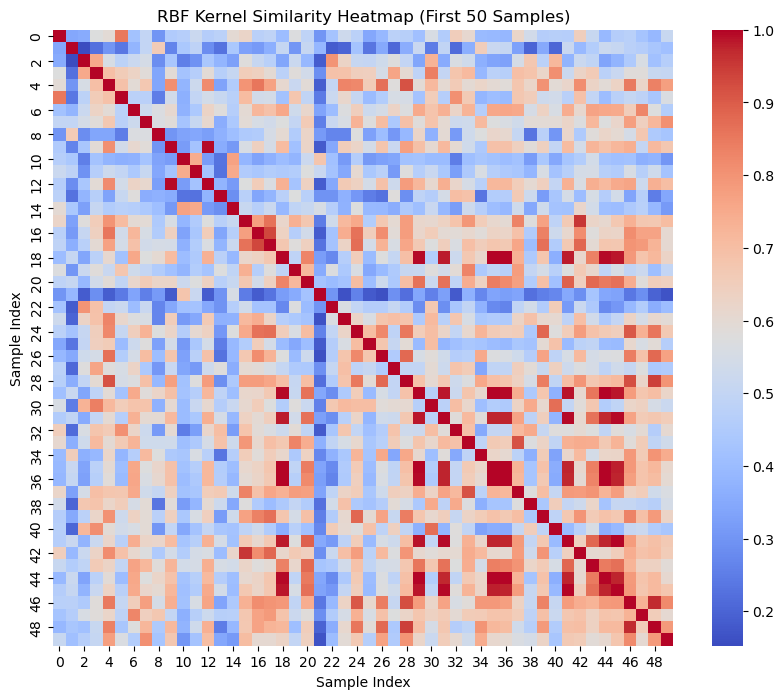

In [13]:
# Step 13: RBF kernel influence visualization
from sklearn.metrics.pairwise import rbf_kernel

# Compute kernel matrix on a small subset
subset = X_train_transformed[:300]
kernel_matrix = rbf_kernel(subset)

plt.figure(figsize=(10,8))
sns.heatmap(kernel_matrix[:50, :50], cmap="coolwarm")
plt.title("RBF Kernel Similarity Heatmap (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Sample Index")

plt.savefig("Obesity-Risk-ML-Classification/Model_4_Support Vector Machine (SVM)/reports/figures/kernal_similarity_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


Step 14 – Retrain SVM on full training data

In [14]:
# Step 14 (SVM): Retrain on full training data
svm_pipeline.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model', SVC(random_state=42))])

Step 15 - Save trained SVM pipeline

In [15]:
# Step 15: Save trained SVM pipeline

import pickle

with open("svm_model.pkl", "wb") as f:

    pickle.dump(svm_pipeline, f)

print("SVM model saved as svm_model.pkl")

SVM model saved as svm_model.pkl


Step 16 – Predict on test set with SVM

In [16]:
# Step 16 (SVM): Predict on Kaggle test data
test_preds_svm = svm_pipeline.predict(X_test)

print(test_preds_svm[:10])


['Obesity_Type_II' 'Overweight_Level_I' 'Obesity_Type_III'
 'Obesity_Type_I' 'Obesity_Type_III' 'Insufficient_Weight'
 'Insufficient_Weight' 'Normal_Weight' 'Overweight_Level_II'
 'Normal_Weight']


Step 17 – Build submission file (SVM)

In [17]:
# Step 17: Build submission file
submission_svm = sample_submission.copy()
submission_svm["NObeyesdad"] = test_preds_svm

submission_svm.head()



,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


Step 18 — Save CSV for Kaggle Submission

In [18]:
# Step 18: Save SVM submission
submission_svm.to_csv("submission_svm.csv", index=False)
